In [1]:
# imports

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# imports for OLS / Anova
import statsmodels.formula.api as smf
import statsmodels.api as sm

# imports for function
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [2]:
pd.set_option('display.max_rows', 750)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', None)

In [3]:
# extract load

In [4]:
ls -lh ./data

total 13G
-rw-r--r-- 1 mijka mijka 166M 10 août  17:20 clean_openfoodfacts_2.csv
-rw-r--r-- 1 mijka mijka 166M  3 août  17:36 clean_openfoodfacts.csv
-rw-r--r-- 1 mijka mijka 166M 19 oct.  09:30 clean_openfoodfacts_x.csv
-rw-r--r-- 1 mijka mijka 5,6G 22 avril  2022 en.openfoodfacts.org.products.csv
-rw-r--r-- 1 mijka mijka 5,7G 22 avril  2022 fr.openfoodfacts.org.products.csv
-rw-r--r-- 1 mijka mijka 809M 21 avril  2017 fr.openfoodfacts.org.products_old.csv


In [5]:
path = './data/'
csv_path = path + 'clean_openfoodfacts.csv'
df = pd.read_csv(csv_path, low_memory=False)

In [6]:
df.rename(columns = {'energy-kcal_100g':'energy_kcal_100g'}, inplace=True)

In [7]:
df.head()

,product_name,pnns_groups_1,pnns_groups_2,code,energy_kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
0,jeunes pousses,unknown,unknown,00000000000000225,173.0,4.1,1.0,8.8,1.90,6.0,0.725,0.290598
1,L.casei,unknown,unknown,00000000000003429145,173.0,1.4,0.9,9.8,9.80,2.7,0.100,0.040000
2,Cacao,unknown,unknown,0000000000031,173.0,4.1,1.0,8.8,1.90,6.0,0.725,0.290598
3,Filetes de pollo empanado,unknown,unknown,000000000003327986,163.9,1.9,1.0,8.8,1.90,15.3,1.100,0.440000
4,Burger Meat Pollo,unknown,unknown,000000000004128579,194.0,11.0,3.9,5.7,0.05,18.0,0.725,0.290598


In [8]:
df.shape

(1708030, 12)

In [9]:
df.describe()

,energy_kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
count,1.708030e+06,1.708030e+06,1.708030e+06,1.708030e+06,1.708030e+06,1.708030e+06,1.708030e+06,1.708030e+06
mean,1.944011e+02,8.390854e+00,2.918876e+00,1.540389e+01,4.218780e+00,8.406179e+00,1.105947e+00,4.580106e-01
std,1.363982e+02,1.161723e+01,5.271329e+00,1.903835e+01,7.153846e+00,9.301487e+00,2.347372e+00,1.263190e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+02,1.300000e+00,2.000000e-01,3.570000e+00,6.000000e-01,2.200000e+00,1.900000e-01,7.600000e-02
50%,1.730000e+02,4.100000e+00,1.000000e+00,8.800000e+00,1.900000e+00,6.000000e+00,7.250000e-01,2.905983e-01
75%,2.610000e+02,1.000000e+01,2.700000e+00,1.666670e+01,4.000000e+00,1.100000e+01,1.160714e+00,4.666667e-01
max,8.995633e+02,9.999000e+01,9.990000e+01,9.996000e+01,9.990000e+01,9.990000e+01,7.142750e+01,9.398000e+01


In [10]:
#missing data
df.isnull().sum()

product_name          0
pnns_groups_1         0
pnns_groups_2         0
code                  0
energy_kcal_100g      0
fat_100g              0
saturated-fat_100g    0
carbohydrates_100g    0
sugars_100g           0
proteins_100g         0
salt_100g             0
sodium_100g           0
dtype: int64

# Univariate analysis

In [11]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1708030 entries, 0 to 1708029
Data columns (total 12 columns):
 #   Column              Dtype  
---  ------              -----  
 0   product_name        object 
 1   pnns_groups_1       object 
 2   pnns_groups_2       object 
 3   code                object 
 4   energy_kcal_100g    float64
 5   fat_100g            float64
 6   saturated-fat_100g  float64
 7   carbohydrates_100g  float64
 8   sugars_100g         float64
 9   proteins_100g       float64
 10  salt_100g           float64
 11  sodium_100g         float64
dtypes: float64(8), object(4)
memory usage: 156.4+ MB


## Numerical variables

In [12]:
num_cols = df.columns[df.dtypes == 'float64']
num_cols

Index(['energy_kcal_100g', 'fat_100g', 'saturated-fat_100g',
       'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
       'sodium_100g'],
      dtype='object')

In [13]:
df.dtypes[df.dtypes == 'float64'].size

8

There's 8 numerical variables, that could be split into 2 groups regarding their different units of measurement / orders of magnitude :

- nutrients (less than 100g per 100g)
- energy (less than 900 Cal per 100g)

In [14]:
nutrients = ['fat_100g', 'saturated-fat_100g',
       'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
       'sodium_100g']
energy = ['energy-kcal_100g']

##

fats = ['fat_100g', 'saturated-fat_100g']
sugars = ['carbohydrates_100g', 'sugars_100g']
other = ['proteins_100g', 'salt_100g',
       'sodium_100g']

In [15]:
def UVA_numeric2(data, i):
  '''
  Univariate_Analysis_numeric
  takes a group of variables (INTEGER and FLOAT) and plot/print all the descriptives and properties along with KDE.

  Runs a loop: calculate all the descriptives of i(th) variable and plot/print it
  '''
  # calculating descriptives of variable
  mini = data[i].min()
  maxi = data[i].max()
  ran = data[i].max()-data[i].min()
  mean = data[i].mean()
  median = data[i].median()
  st_dev = data[i].std()
  skew = data[i].skew()
  kurt = data[i].kurtosis()

  # calculating points of standard deviation
  points = mean-st_dev, mean+st_dev

  #Plotting the variable with every information
  sns.kdeplot(data[i], shade=True)
  sns.lineplot(points, [0,0], color = 'black', label = "std_dev")
  sns.scatterplot([mini,maxi], [0,0], color = 'orange', label = "min/max")
  sns.scatterplot([mean], [0], color = 'red', label = "mean")
  sns.scatterplot([median], [0], color = 'blue', label = "median")
  plt.xlabel('{}'.format(i), fontsize = 20)
  plt.ylabel('density')
  plt.title('std_dev = {}; kurtosis = {};\nskew = {}; range = {}\nmean = {}; median = {}'.format((round(points[0],2),round(points[1],2)),
                                                                                                   round(kurt,2),
                                                                                                   round(skew,2),
                                                                                                   (round(mini,2),round(maxi,2),round(ran,2)),
                                                                                                   round(mean,2),
                                                                                                   round(median,2)))

In [16]:
# afficher détail Boxplot / UVA_num pour chaque indicateur par ligne

def UVA_num_plus(df, indicators_list):
  
    for i in indicators_list:
        plt.figure(figsize = (15, 20))
        df_indic = df[i]

        plt.subplot(5,2,1)
        sns.boxplot(y=df_indic)
        plt.xlabel(f'{i}', fontsize = 20)


        plt.subplot(5,2,2)
        UVA_numeric2(df, i)


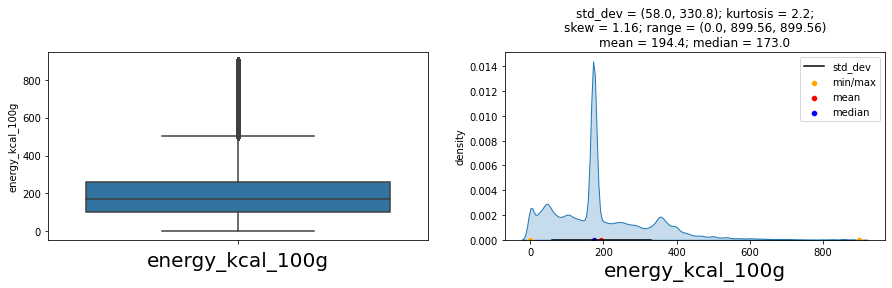

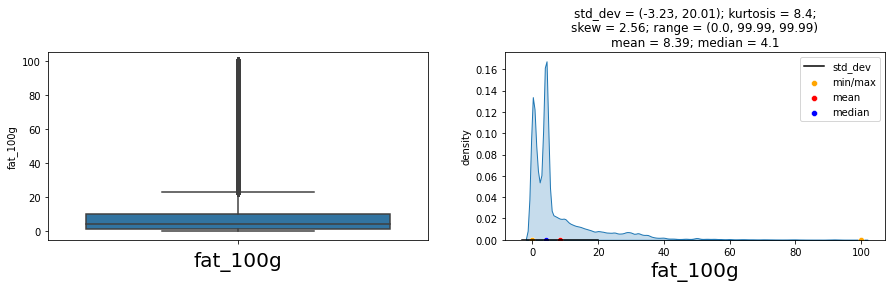

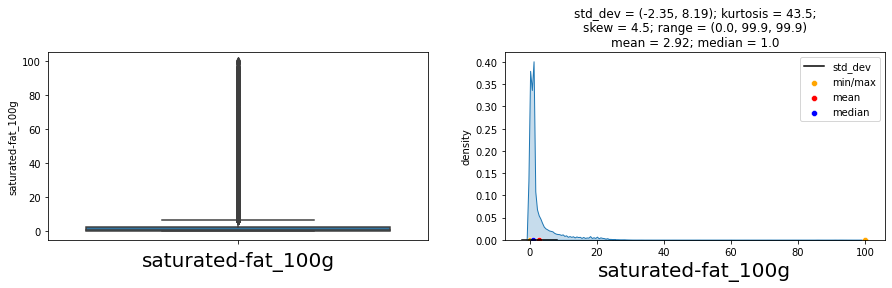

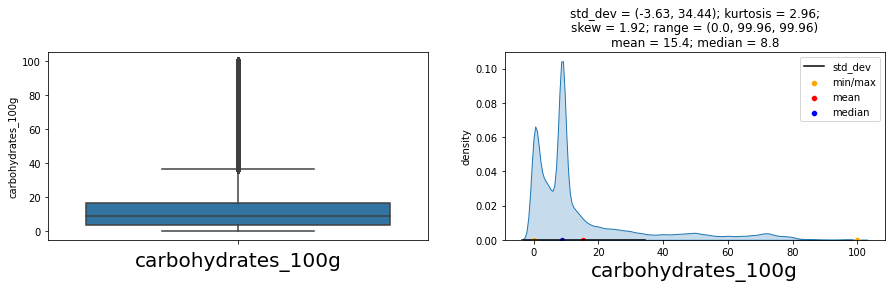

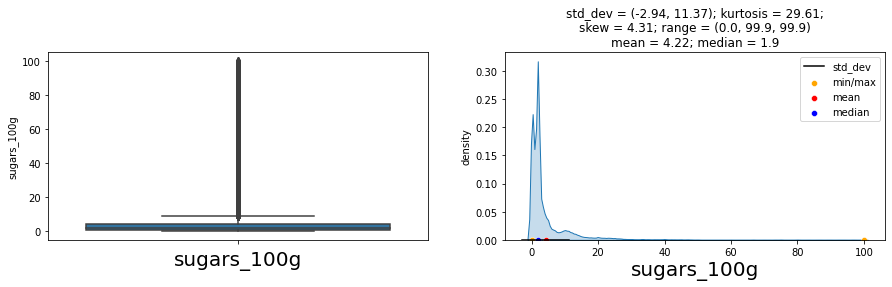

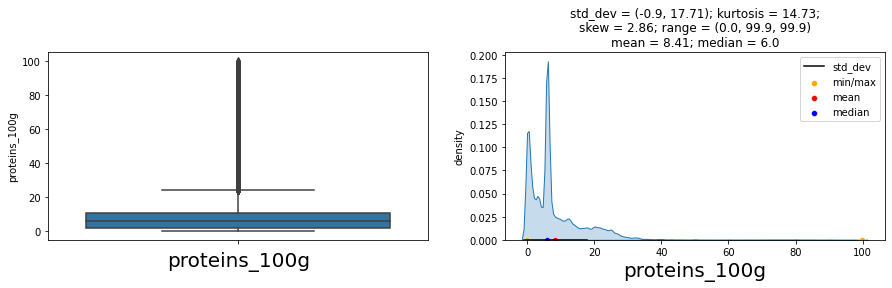

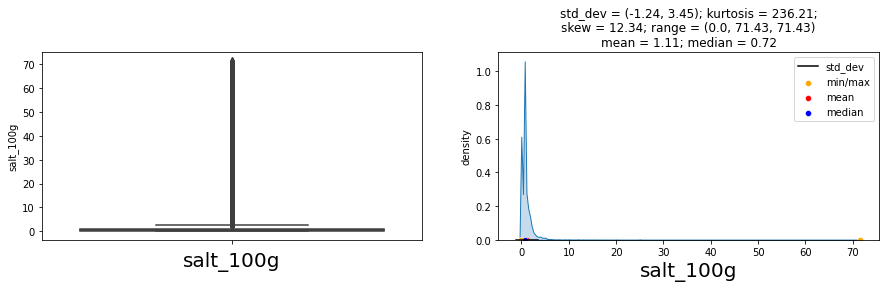

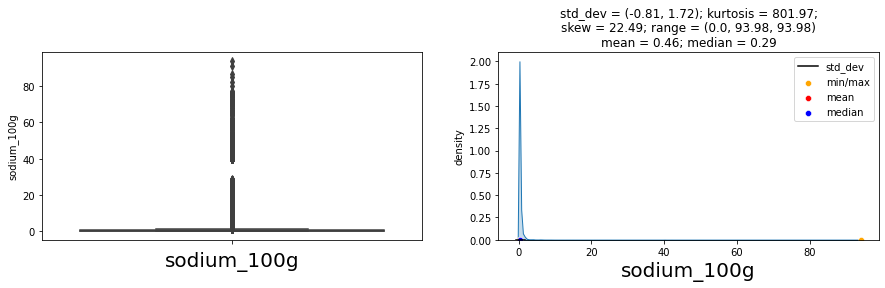

In [17]:
UVA_num_plus(df, num_cols)

### Comparison with univariates from un-cleaned data source

In [18]:
old_path = path + 'fr.openfoodfacts.org.products.csv'
columns = ['product_name', 'pnns_groups_1', 'pnns_groups_2', 'code',
        'fat_100g', 'saturated-fat_100g',
       'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
       'sodium_100g']

In [19]:
df_old = pd.read_csv(old_path, sep='\t', header='infer', on_bad_lines='skip', low_memory=False)

In [20]:
df_old = df_old[columns]

In [21]:
df_old.shape

(2282517, 11)

In [22]:
old_num_cols = df_old.columns[df_old.dtypes == 'float64']
old_num_cols

Index(['fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g',
       'proteins_100g', 'salt_100g', 'sodium_100g'],
      dtype='object')

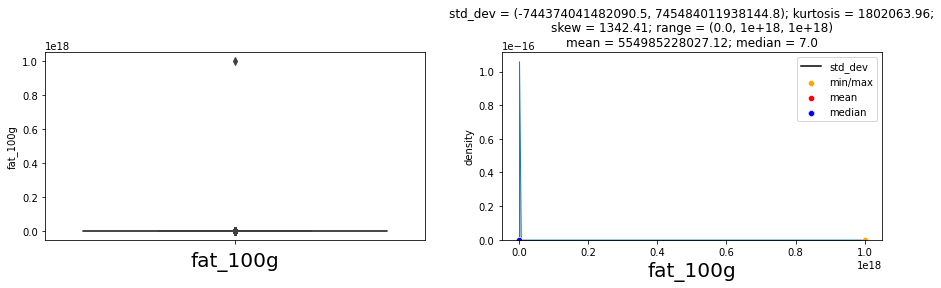

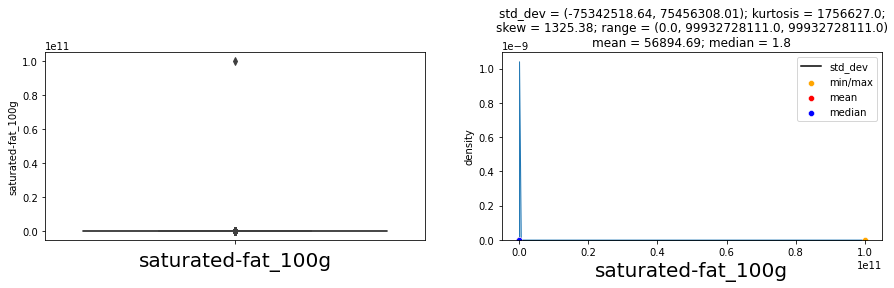

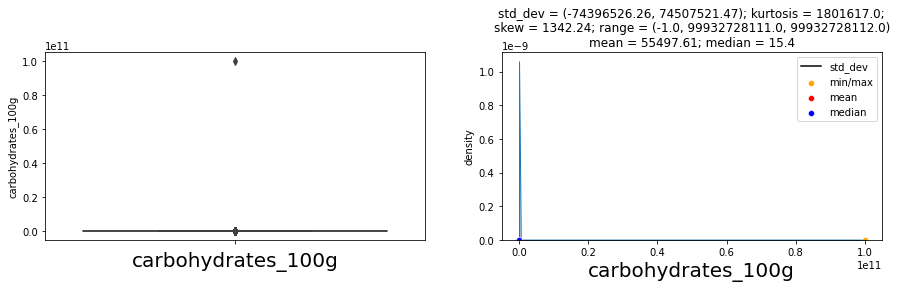

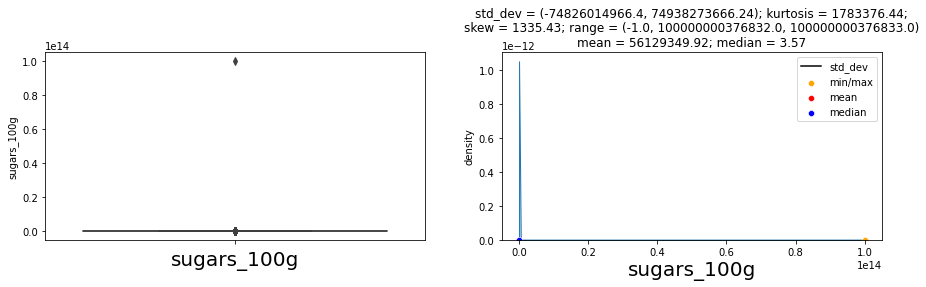

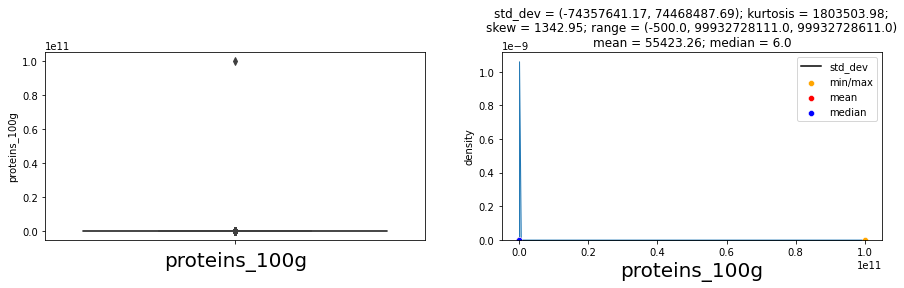

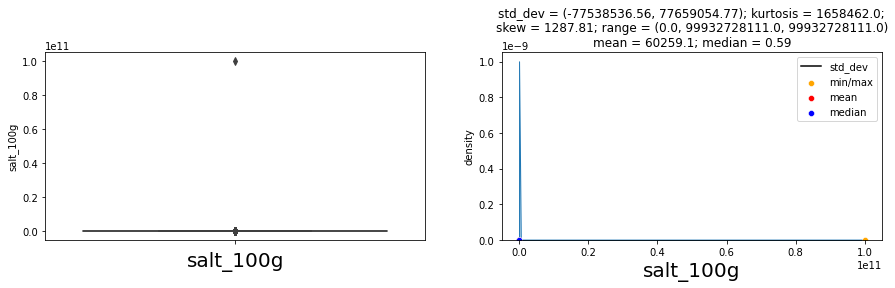

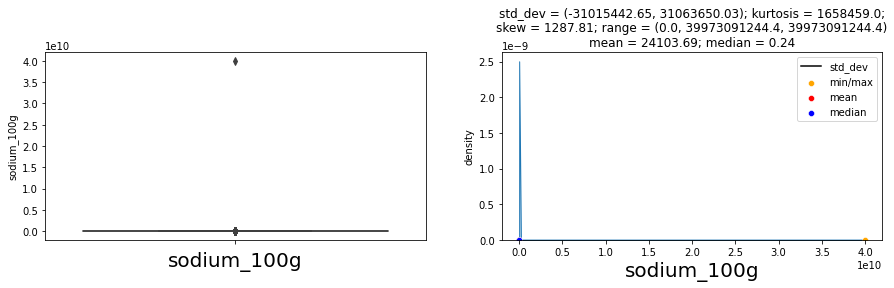

In [23]:
UVA_num_plus(df_old, old_num_cols)

## Categorical variables

In [24]:
mylist = df['pnns_groups_1'].unique()
mylist

array(['unknown', 'Fat and sauces', 'Composite foods', 'Sugary snacks',
       'Fruits and vegetables', 'Fish Meat Eggs', 'Beverages',
       'Milk and dairy products', 'Cereals and potatoes', 'Salty snacks',
       'Alcoholic beverages', 'sugary-snacks'], dtype=object)

In [25]:
n =10

newlist = mylist[:n]
newlist

array(['unknown', 'Fat and sauces', 'Composite foods', 'Sugary snacks',
       'Fruits and vegetables', 'Fish Meat Eggs', 'Beverages',
       'Milk and dairy products', 'Cereals and potatoes', 'Salty snacks'],
      dtype=object)

In [26]:
cats = ['pnns_groups_1', 'pnns_groups_2']

In [27]:
# Custom function for easy visualisation of Categorical Variables
def UVA_category(data, var_group, width=7, height=5):

  '''
  Univariate_Analysis_categorical
  takes a group of variables (category) and plot/print all the value_counts and barplot.
  '''
  # setting figure_size
  size = len(var_group)
  plt.figure(figsize = (width*size, height), dpi = 100)

  # for every variable
  for j,i in enumerate(var_group):
    norm_count = data[i].value_counts(normalize = True)
    n_uni = data[i].nunique()

  #Plotting the variable with every information
    plt.subplot(1,size,j+1)
    sns.barplot(norm_count, norm_count.index , order = norm_count.index)
    plt.xlabel('fraction/percent', fontsize = 20)
    plt.ylabel('{}'.format(i), fontsize = 20)
    plt.title('n_uniques = {} \n value counts \n {};'.format(n_uni,norm_count))

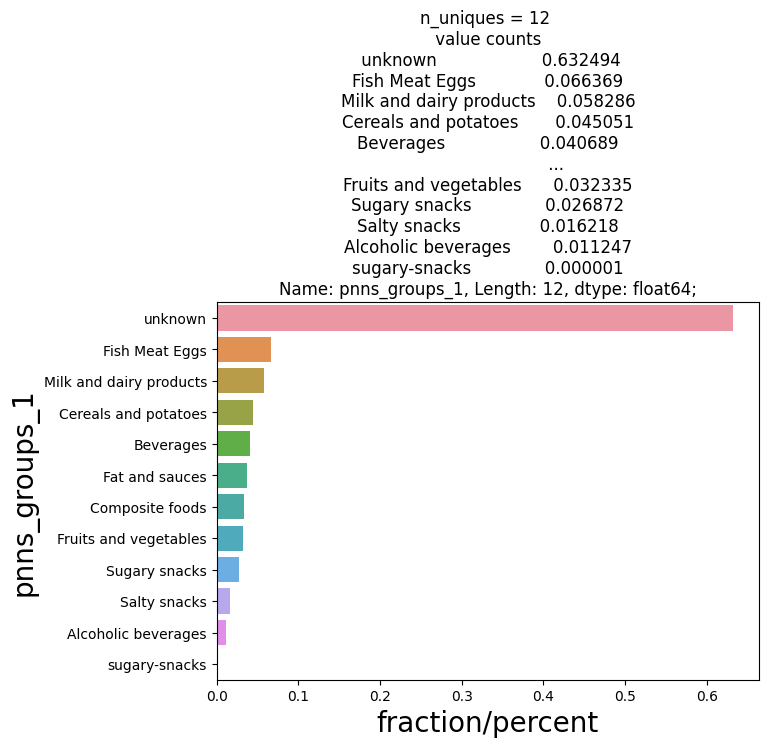

In [28]:
pd.set_option('display.max_rows', 10)
UVA_category(df, ['pnns_groups_1'])

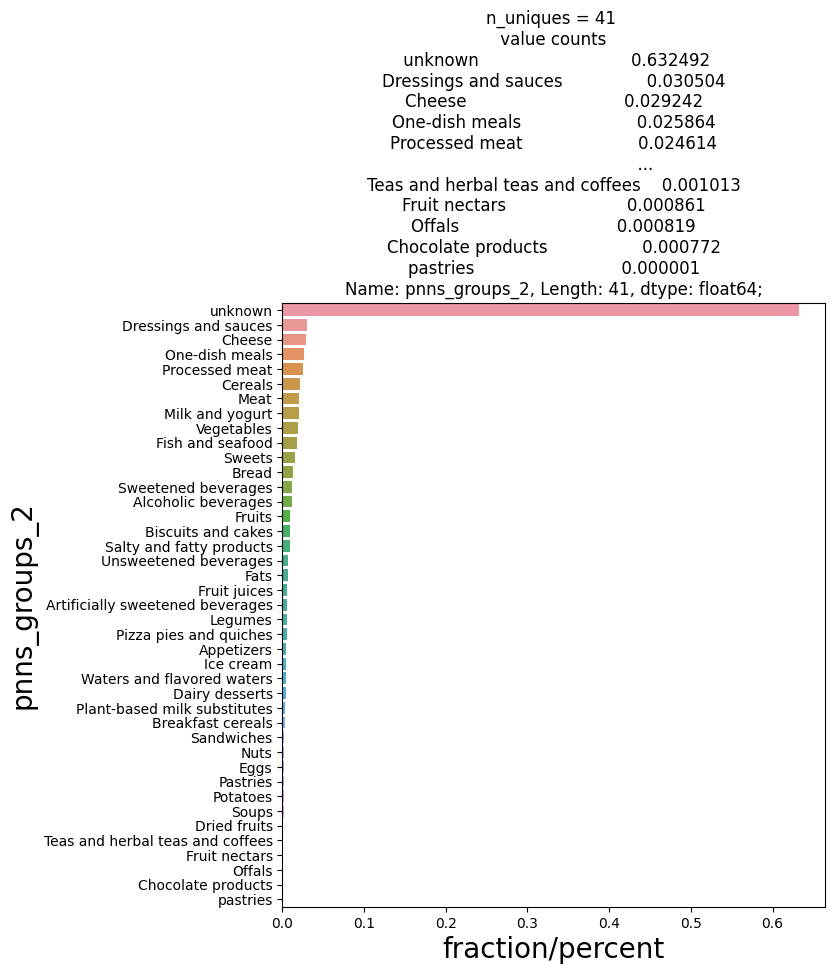

In [29]:
UVA_category(df, ['pnns_groups_2'], 7, 8)

### pie charts

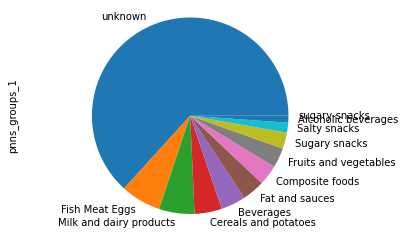

In [30]:
# Diagramme en secteurs
df['pnns_groups_1'].value_counts(normalize=True).plot(kind='pie')
plt.axis('equal') 
plt.show()

In [31]:
#colors = sns.color_palette('pastel')[0:5]

#plt.pie(df['pnns_groups_2'], colors = colors, autopct='%.0f%%')
#plt.show()

In [32]:
# scatter plot



# Bi-variate

=> ajouter graphs num / num & cat/cat & num/cat

In [33]:
df.head()

,product_name,pnns_groups_1,pnns_groups_2,code,energy_kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
0,jeunes pousses,unknown,unknown,00000000000000225,173.0,4.1,1.0,8.8,1.90,6.0,0.725,0.290598
1,L.casei,unknown,unknown,00000000000003429145,173.0,1.4,0.9,9.8,9.80,2.7,0.100,0.040000
2,Cacao,unknown,unknown,0000000000031,173.0,4.1,1.0,8.8,1.90,6.0,0.725,0.290598
3,Filetes de pollo empanado,unknown,unknown,000000000003327986,163.9,1.9,1.0,8.8,1.90,15.3,1.100,0.440000
4,Burger Meat Pollo,unknown,unknown,000000000004128579,194.0,11.0,3.9,5.7,0.05,18.0,0.725,0.290598


In [34]:
# cat / num

In [35]:
x = df['pnns_groups_1']
y = df['energy_kcal_100g']

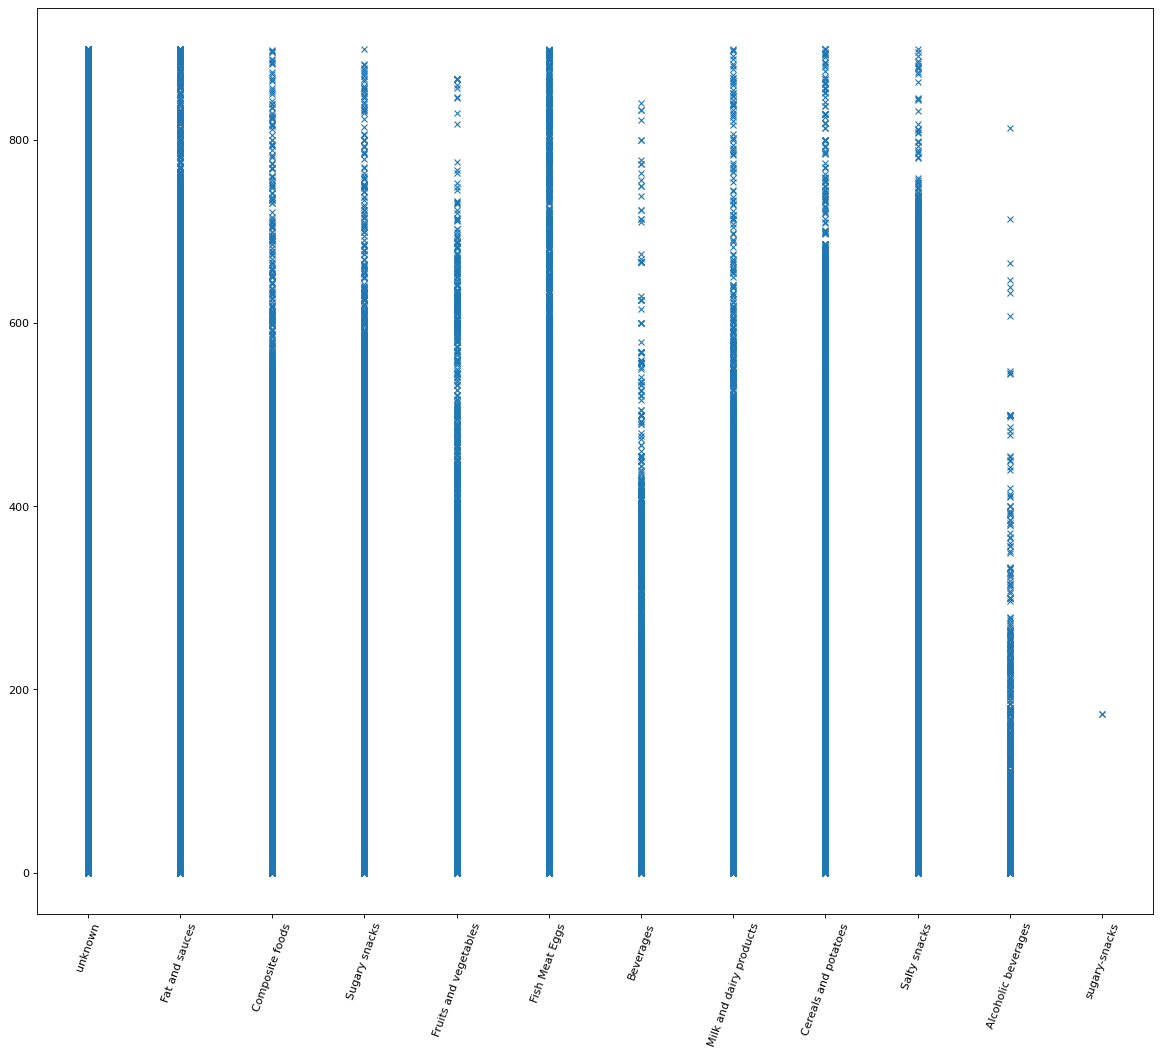

In [36]:
plt.figure(figsize=(18, 15), dpi=80)
plt.xticks(rotation=70)
plt.plot(x, y, 'x')
plt.show()

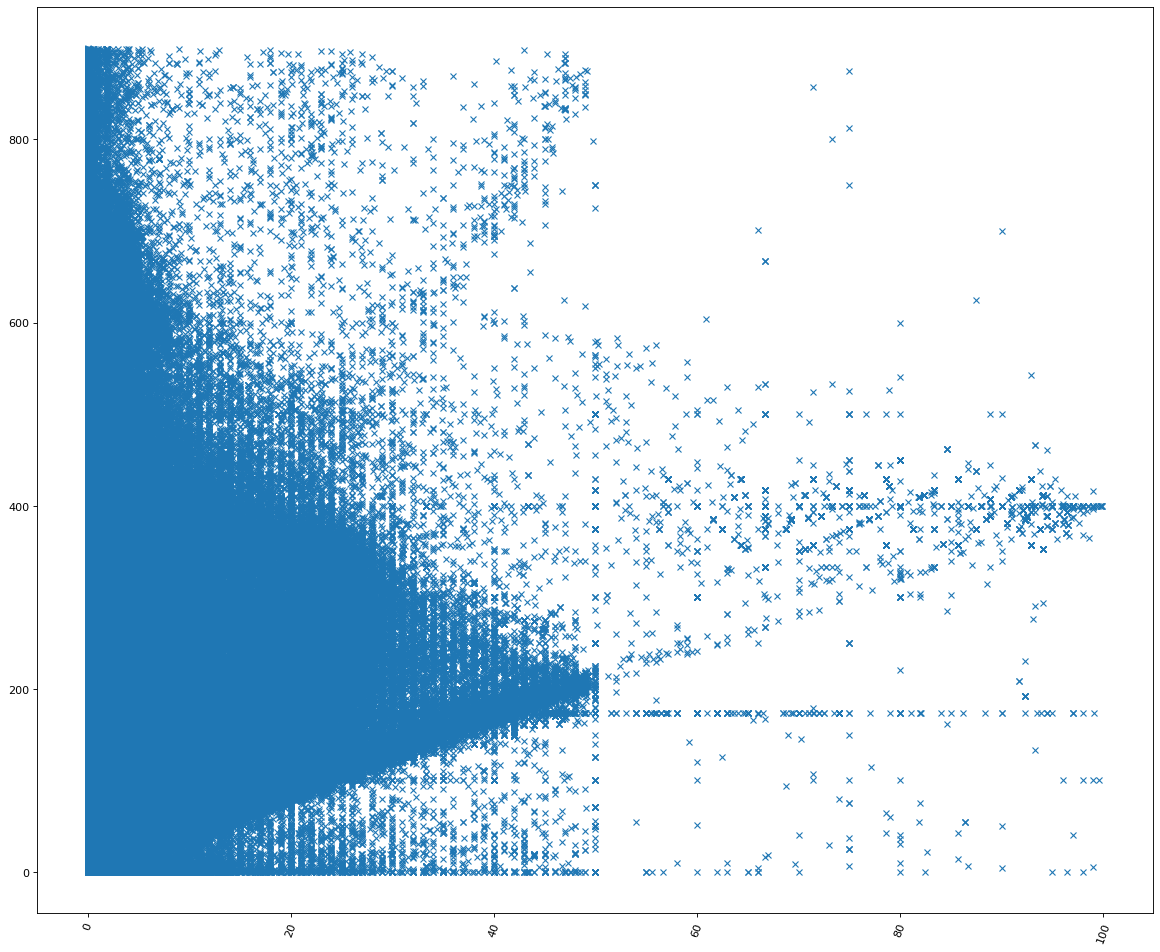

In [37]:
# num / num

plt.figure(figsize=(18, 15), dpi=80)
plt.xticks(rotation=70)
x = df['sugars_100g']
y = df['energy_kcal_100g']
plt.plot(x,y, 'x')
plt.show()
# titres
#taille

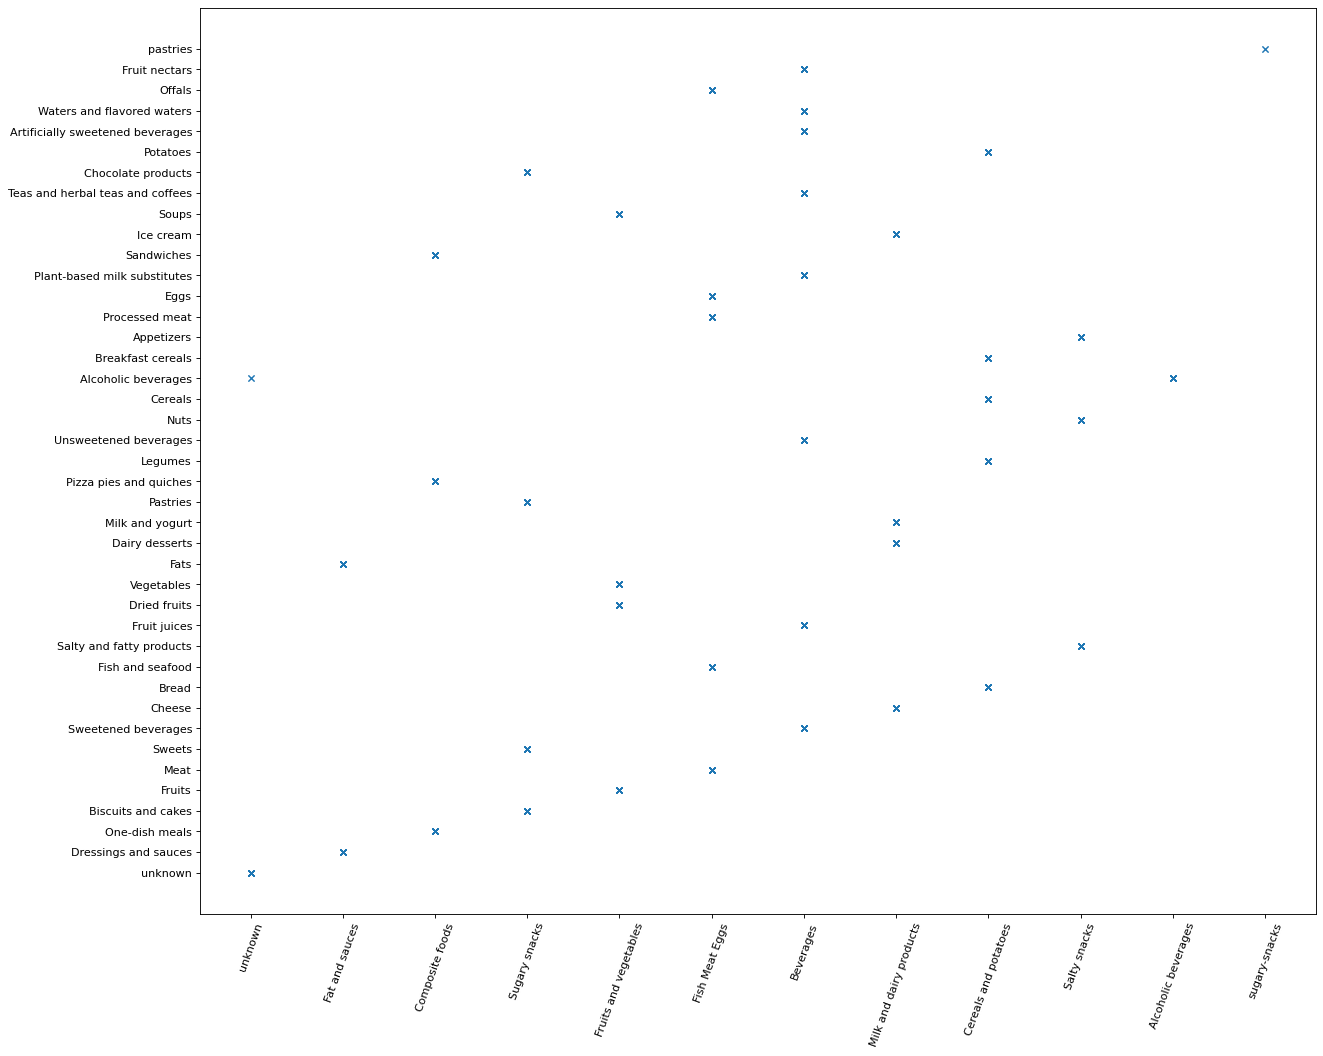

In [38]:
# cat / cat 

plt.figure(figsize=(18, 15), dpi=80)
plt.xticks(rotation=70)
x = df['pnns_groups_1']
y = df['pnns_groups_2']
plt.plot(x,y, 'x')
plt.show()

# Multi-variate


## Correlation Matrix

In [39]:
num_cols

Index(['energy_kcal_100g', 'fat_100g', 'saturated-fat_100g',
       'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
       'sodium_100g'],
      dtype='object')

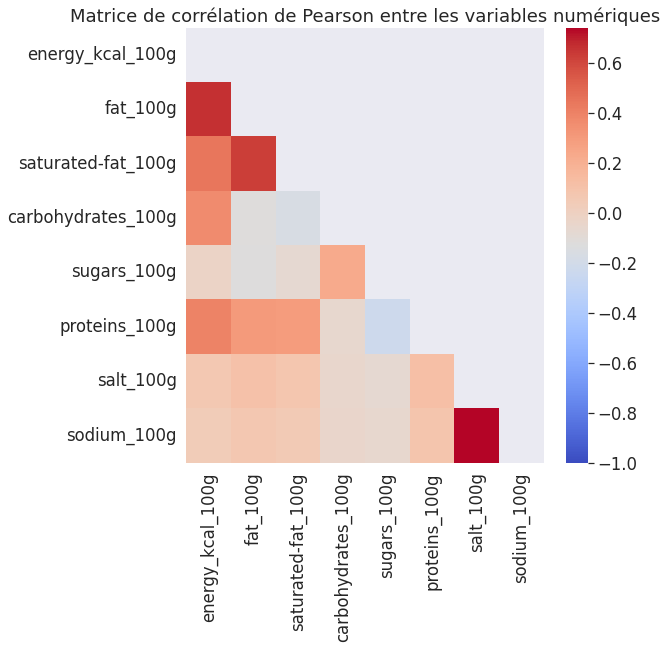

In [40]:
plt.figure(figsize=(8,8))
sns.set(font_scale=1.5)
plt.title('Matrice de corrélation de Pearson entre les variables numériques')

corr = df.corr()

mask = np.zeros_like(corr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True 

ax = sns.heatmap(corr, mask=mask, vmin=-1, cmap='coolwarm')
plt.show()
sns.set(font_scale=1)

On peut retirer du tableau les informations suivantes :

- **fat_100g** et **saturated-fat_100g** sont fortement corrélés
- **energy-kcal_100g** : forte corrélation avec :
  - fat_100g
  - saturated-fat_100g
  - carbohydrates_100g
  - proteins_100g
- **sodium_100g** et **salt_100g** sont fortement corrélés
- **sugars_100g** sont corrélés avec **carbohydrates_100g**

# Multi-variate analysis

##  Analyse de la variance (ANOVA)

In [41]:
df[num_cols].head()

,energy_kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
0,173.0,4.1,1.0,8.8,1.90,6.0,0.725,0.290598
1,173.0,1.4,0.9,9.8,9.80,2.7,0.100,0.040000
2,173.0,4.1,1.0,8.8,1.90,6.0,0.725,0.290598
3,163.9,1.9,1.0,8.8,1.90,15.3,1.100,0.440000
4,194.0,11.0,3.9,5.7,0.05,18.0,0.725,0.290598


In [42]:
df.head()

,product_name,pnns_groups_1,pnns_groups_2,code,energy_kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
0,jeunes pousses,unknown,unknown,00000000000000225,173.0,4.1,1.0,8.8,1.90,6.0,0.725,0.290598
1,L.casei,unknown,unknown,00000000000003429145,173.0,1.4,0.9,9.8,9.80,2.7,0.100,0.040000
2,Cacao,unknown,unknown,0000000000031,173.0,4.1,1.0,8.8,1.90,6.0,0.725,0.290598
3,Filetes de pollo empanado,unknown,unknown,000000000003327986,163.9,1.9,1.0,8.8,1.90,15.3,1.100,0.440000
4,Burger Meat Pollo,unknown,unknown,000000000004128579,194.0,11.0,3.9,5.7,0.05,18.0,0.725,0.290598


<function matplotlib.pyplot.show(close=None, block=None)>

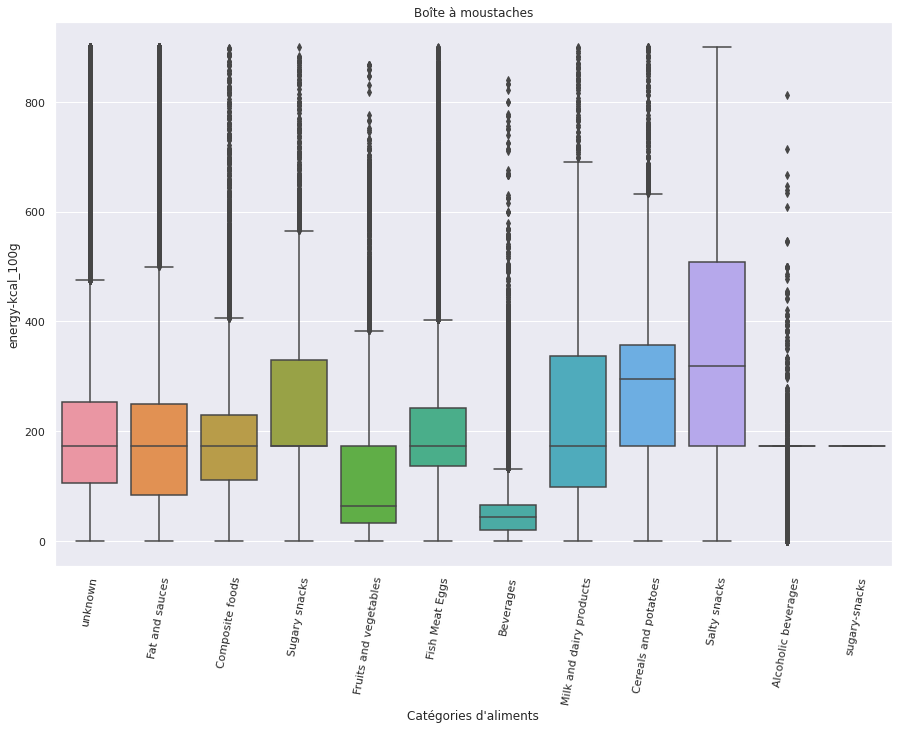

In [43]:
sns.set()
plt.figure(figsize = (15, 10))
plt.xticks(rotation=80)
ax = sns.boxplot(x='pnns_groups_1', y='energy_kcal_100g', data=df)
plt.xlabel("Catégories d'aliments")
plt.ylabel('energy-kcal_100g')
plt.title('Boîte à moustaches')
plt.show

Les 12 catégories semblent différentes, il faut maintenant voir si les écarts sont significatifs ou pas grâce à l'ANOVA

=>  interpreting OLS summary results :

- [link1](https://statisticsbyjim.com/regression/interpret-coefficients-p-values-regression/)
- [link2](https://www.geeksforgeeks.org/interpreting-the-results-of-linear-regression-using-ols-summary/)
- [link3](https://jyotiyadav99111.medium.com/statistics-how-should-i-interpret-results-of-ols-3bde1ebeec01)



In [44]:
# standard scale before anova ?

In [45]:
anova_category_nrj = smf.ols('energy_kcal_100g~pnns_groups_1', data=df).fit()
print(anova_category_nrj.summary())

                            OLS Regression Results                            
Dep. Variable:       energy_kcal_100g   R-squared:                       0.095
Model:                            OLS   Adj. R-squared:                  0.095
Method:                 Least Squares   F-statistic:                 1.639e+04
Date:                Wed, 09 Nov 2022   Prob (F-statistic):               0.00
Time:                        10:00:56   Log-Likelihood:            -1.0734e+07
No. Observations:             1708030   AIC:                         2.147e+07
Df Residuals:                 1708018   BIC:                         2.147e+07
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

Tableau de l'analyse de la variance :

In [46]:
sm.stats.anova_lm(anova_category_nrj, typ=2)

,sum_sq,df,F,PR(>F)
pnns_groups_1,3.033714e+09,11.0,16388.458913,0.0
Residual,2.874328e+10,1708018.0,NaN,NaN


In [47]:
anova_category_fat = smf.ols('fat_100g~pnns_groups_1', data=df).fit()
print(anova_category_fat.summary())

                            OLS Regression Results                            
Dep. Variable:               fat_100g   R-squared:                       0.105
Model:                            OLS   Adj. R-squared:                  0.105
Method:                 Least Squares   F-statistic:                 1.816e+04
Date:                Wed, 09 Nov 2022   Prob (F-statistic):               0.00
Time:                        10:01:03   Log-Likelihood:            -6.5180e+06
No. Observations:             1708030   AIC:                         1.304e+07
Df Residuals:                 1708018   BIC:                         1.304e+07
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

Tableau d'analyse de la variance :

In [48]:
sm.stats.anova_lm(anova_category_fat, typ=2)

,sum_sq,df,F,PR(>F)
pnns_groups_1,2.414200e+07,11.0,18164.291176,0.0
Residual,2.063738e+08,1708018.0,NaN,NaN


In [49]:
anova_category2_nrj = smf.ols('energy_kcal_100g~pnns_groups_2', data=df).fit()
print(anova_category2_nrj.summary())

                            OLS Regression Results                            
Dep. Variable:       energy_kcal_100g   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     7339.
Date:                Wed, 09 Nov 2022   Prob (F-statistic):               0.00
Time:                        10:01:18   Log-Likelihood:            -1.0684e+07
No. Observations:             1708030   AIC:                         2.137e+07
Df Residuals:                 1707989   BIC:                         2.137e+07
Df Model:                          40                                         
Covariance Type:            nonrobust                                         
                                                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------

In [50]:
sm.stats.anova_lm(anova_category2_nrj, typ=2)

,sum_sq,df,F,PR(>F)
pnns_groups_2,4.660879e+09,40.0,7339.484775,0.0
Residual,2.711611e+10,1707989.0,NaN,NaN


## PCA

In [51]:
#features = df.columns[df.dtypes == 'float64']
#features

In [52]:
#features.size

In [53]:
# toutes features
# transformer variables categorielles en nombres (ex : ordinalEncoder +++ / OneHotEncoder)


In [54]:
dfc = df.copy()

In [55]:
dfc.drop(columns=['product_name', 'code'], inplace=True)

In [56]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1708030 entries, 0 to 1708029
Data columns (total 10 columns):
 #   Column              Dtype  
---  ------              -----  
 0   pnns_groups_1       object 
 1   pnns_groups_2       object 
 2   energy_kcal_100g    float64
 3   fat_100g            float64
 4   saturated-fat_100g  float64
 5   carbohydrates_100g  float64
 6   sugars_100g         float64
 7   proteins_100g       float64
 8   salt_100g           float64
 9   sodium_100g         float64
dtypes: float64(8), object(2)
memory usage: 130.3+ MB


In [57]:
cat_cols = ['pnns_groups_1', 'pnns_groups_2']

In [58]:
## enlever product_name & code

In [59]:
dfc[cat_cols].head()

,pnns_groups_1,pnns_groups_2
0,unknown,unknown
1,unknown,unknown
2,unknown,unknown
3,unknown,unknown
4,unknown,unknown


In [60]:
# encoding categories
from sklearn.preprocessing import OrdinalEncoder

enc = OrdinalEncoder()
dfc[cat_cols] = enc.fit_transform(dfc[cat_cols])

In [61]:
dfc.head()

,pnns_groups_1,pnns_groups_2,energy_kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
0,11.0,40.0,173.0,4.1,1.0,8.8,1.90,6.0,0.725,0.290598
1,11.0,40.0,173.0,1.4,0.9,9.8,9.80,2.7,0.100,0.040000
2,11.0,40.0,173.0,4.1,1.0,8.8,1.90,6.0,0.725,0.290598
3,11.0,40.0,163.9,1.9,1.0,8.8,1.90,15.3,1.100,0.440000
4,11.0,40.0,194.0,11.0,3.9,5.7,0.05,18.0,0.725,0.290598


In [62]:
def clean_data(data, select_X=None, impute=False, std=False): 
    """Returns dataframe with selected, imputed 
       and standardized features
    
    Input
          data: dataframe
          select_X: list of feature names to be selected (string)
          impute: If True impute np.nan with mean
          std: If True standardize data
          
    Return
        dataframe: data with selected, imputed 
                   and standardized features    
    """
    
    # (i.) select features
    if select_X is not None:
        data = data.filter(select_X, axis='columns')
        print("\t>>> Selected features: {}".format(select_X))
    else:
        # store column names
        select_X = list(data.columns)
    
    # (ii.) impute with mean 
    if impute:
        imp = SimpleImputer()
        data = imp.fit_transform(data)
        print("\t>>> Imputed missings")
    
    # (iii.) standardize 
    if std:
        std_scaler = StandardScaler()
        data = std_scaler.fit_transform(data)
        print("\t>>> Standardized data")
    
    return pd.DataFrame(data, columns=select_X)

#  (iv.) select relevant features 
selected_features = ['pnns_groups_1', 'pnns_groups_2', 'energy_kcal_100g', 'fat_100g',
       'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g',
       'proteins_100g', 'salt_100g', 'sodium_100g']

# (v.) select features, impute missings and standardize
X_std = clean_data(dfc, selected_features, impute=True, std=True)

	>>> Selected features: ['pnns_groups_1', 'pnns_groups_2', 'energy_kcal_100g', 'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g', 'sodium_100g']
	>>> Imputed missings
	>>> Standardized data


In [63]:
X_std.head()

,pnns_groups_1,pnns_groups_2,energy_kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
0,0.684833,0.639405,-0.156902,-0.369353,-0.364021,-0.346873,-0.324131,-0.258688,-0.162287,-0.132531
1,0.684833,0.639405,-0.156902,-0.601766,-0.382992,-0.294348,0.780171,-0.613470,-0.428542,-0.330917
2,0.684833,0.639405,-0.156902,-0.369353,-0.364021,-0.346873,-0.324131,-0.258688,-0.162287,-0.132531
3,0.684833,0.639405,-0.223618,-0.558726,-0.364021,-0.346873,-0.324131,0.741153,-0.002534,-0.014258
4,0.684833,0.639405,-0.002941,0.224593,0.186125,-0.509703,-0.582733,1.031429,-0.162287,-0.132531


In [64]:
X_std.shape[1]

10

In [65]:
# Initialize PCA
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_std)

PCA()

In [66]:
# Get basic info
n_components = len(pca.explained_variance_ratio_)
explained_variance = pca.explained_variance_ratio_
cum_explained_variance = np.cumsum(explained_variance)
idx = np.arange(n_components)+1
df_explained_variance = pd.DataFrame([explained_variance, cum_explained_variance], 
                                     index=['explained variance', 'cumulative'], 
                                     columns=idx).T

mean_explained_variance = df_explained_variance.iloc[:,0].mean() # calculate mean explained variance# 


# Print explained variance as plain text
print('Résumé PCA')
print('='*40)
print("Total: {} composants".format(n_components))
print('-'*40)
print('Moyenne de la variance expliquée :', round(mean_explained_variance,3))
print('-'*40)
print(df_explained_variance.head(20))
print('-'*40)

Résumé PCA
Total: 10 composants
----------------------------------------
Moyenne de la variance expliquée : 0.1
----------------------------------------
    explained variance  cumulative
1             0.251719    0.251719
2             0.183806    0.435525
3             0.165769    0.601293
4             0.134887    0.736180
5             0.094456    0.830636
6             0.066787    0.897423
7             0.039894    0.937317
8             0.025744    0.963061
9             0.019960    0.983021
10            0.016979    1.000000
----------------------------------------


Le 1er composant représente 25% de la variance.

Si l'on veut réduire les dimensions existantes et retenir 93% de la variance originale, on peut rester sur 7 composants.


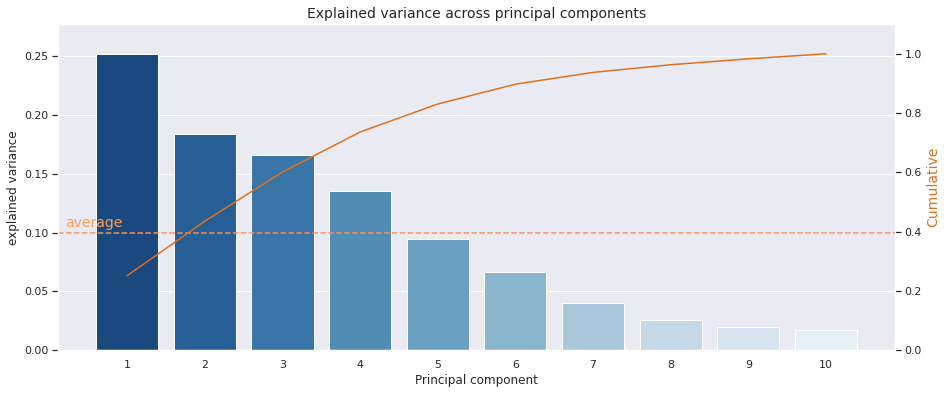

In [67]:
# limit plot to x PC
#limit = int(input("Limit scree plot to nth component (0 for all) > "))
limit = 0
if limit > 0:
    limit_df = limit
else:
    limit_df = n_components
    
df_explained_variance_limited = df_explained_variance.iloc[:limit_df,:]
    
    
# make scree plot
fig, ax1 = plt.subplots(figsize=(15,6))

ax1.set_title('Explained variance across principal components', fontsize=14)
ax1.set_xlabel('Principal component', fontsize=12)
ax1.set_ylabel('Explained variance', fontsize=12)

ax2 = sns.barplot(x=idx[:limit_df], y='explained variance', data=df_explained_variance_limited, palette='Blues_r')
ax2 = ax1.twinx()
ax2.grid(False)
ax2.set_ylabel('Cumulative', fontsize=14, color='#de7021')
ax2 = sns.lineplot(x=idx[:limit_df]-1, y='cumulative', data=df_explained_variance_limited, color='#de7021')

ax1.axhline(mean_explained_variance, ls='--', color='#fc8d59') 

#plot mean
ax1.text(-.8, mean_explained_variance+(mean_explained_variance*.05), "average", color='#fc9d59', fontsize=14)


# label y axis
max_y1 = max(df_explained_variance_limited.iloc[:,0])
max_y2 = max(df_explained_variance_limited.iloc[:,1])
ax1.set(ylim=(0, max_y1+max_y1*.1))
ax2.set(ylim=(0, max_y2+max_y2*.1))
plt.show()

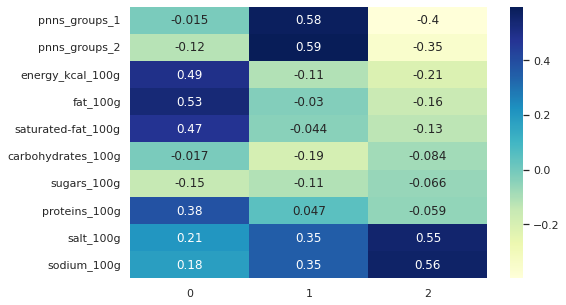

In [68]:
# check factor loading matrix
df_c = pd.DataFrame(pca.components_, columns=selected_features).T

# adjust y-axis size dynamically
size_yaxis = round(X_std.shape[1] * 0.5)
fig, ax = plt.subplots(figsize=(8,size_yaxis))# plot the first top_pc components
top_pc = 3
sns.heatmap(df_c.iloc[:,:top_pc], annot=True, cmap="YlGnBu", ax=ax)
plt.show()

Factor Loadings of 1st PC

Top 5 highest
----------------------------------------
fat_100g              0.530014
energy_kcal_100g      0.490337
saturated-fat_100g    0.473220
proteins_100g         0.379007
salt_100g             0.205705
Name: 0, dtype: float64 

Top 5 lowest
----------------------------------------
sugars_100g          -0.148170
pnns_groups_2        -0.120109
carbohydrates_100g   -0.016810
pnns_groups_1        -0.015014
sodium_100g           0.178515
Name: 0, dtype: float64


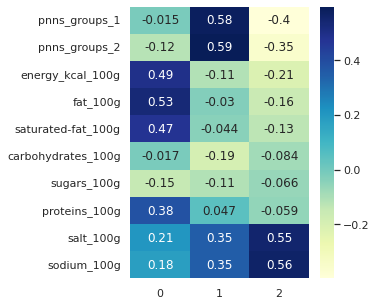

In [69]:
top_k = 5
print("Factor Loadings of 1st PC")
print('='*40,'\n')
print('Top {} highest'.format(top_k))
print('-'*40)
print(df_c.iloc[:,0].sort_values(ascending=False)[:top_k], '\n')

print('Top {} lowest'.format(top_k))
print('-'*40)
print(df_c.iloc[:,0].sort_values()[:top_k])

# Plot heatmap
size_xaxis = round(top_pc * 1.5)
size_yaxis = round(n_components * 0.5)

fig, ax = plt.subplots(figsize=(size_xaxis,size_yaxis))
sns.heatmap(df_c.iloc[:,:top_pc], annot=True, cmap="YlGnBu", ax=ax)
plt.show()

In [70]:
# needing target aka nutriscore ?